# Yelp Data Preprocessing

### Context
1. Dataset Source - Yelp Open Dataset: https://business.yelp.com/data/resources/open-dataset/
2. Focuses on Businesses that are in the "hotel" or "restaurant" industries
3. Maps customer review ratings to sentiment (1-2 = negative, 3 = neutral, 4-5 = positive)

In [ ]:
# Handle imports
import pandas as pd
from matplotlib import pyplot as plt


In [2]:
# Handle constants
CHUNK_SIZE = 10000
SANITY_SIZE = 10
RAND_STATE = 498

In [3]:
# Initialize an empty set to track all business ids that match our search
business_id_set = set()

# To verify the filter works properly
sanity_samples = []

# Use Pandas to read data in chunks to avoid memory crashes
business_chunks = pd.read_json('business.json', lines=True, chunksize=CHUNK_SIZE)

# Process the chunks
for chunk in business_chunks:
    # drop rows without business_id or categories
    chunk = chunk.dropna(subset=['business_id', 'categories'])

    # Define filtering condition
    # Searches for categories containing hotel or restaurant, case insensitive
    # filter = chunk['categories'].str.contains('hotel|restaurant', case=False, na=False)
    filter = chunk['categories'].str.contains('hotel|restaurant', case=False, na=False)

    matching_rows = chunk.loc[filter, ['business_id', 'categories']]

    # Check to ensure categories actually contain our target industries
    if len(sanity_samples) < SANITY_SIZE:
        sanity_samples.extend(matching_rows.to_dict(orient='records'))
        
        # Check first 10 samples
        if len(sanity_samples) >= SANITY_SIZE:
            for i, sample in enumerate(sanity_samples[:SANITY_SIZE], start=1):
                print(f"[{i}] ID: {sample['business_id']}\n    Categories: {sample['categories']}")
                print("-" * 50)


    # Add all matching ids to the set
    business_id_set.update(matching_rows['business_id'])
        


[1] ID: MTSW4McQd7CbVtyjqoe9mw
    Categories: Restaurants, Food, Bubble Tea, Coffee & Tea, Bakeries
--------------------------------------------------
[2] ID: CF33F8-E6oudUQ46HnavjQ
    Categories: Burgers, Fast Food, Sandwiches, Food, Ice Cream & Frozen Yogurt, Restaurants
--------------------------------------------------
[3] ID: k0hlBqXX-Bt0vf1op7Jr1w
    Categories: Pubs, Restaurants, Italian, Bars, American (Traditional), Nightlife, Greek
--------------------------------------------------
[4] ID: bBDDEgkFA1Otx9Lfe7BZUQ
    Categories: Ice Cream & Frozen Yogurt, Fast Food, Burgers, Restaurants, Food
--------------------------------------------------
[5] ID: eEOYSgkmpB90uNA7lDOMRA
    Categories: Vietnamese, Food, Restaurants, Food Trucks
--------------------------------------------------
[6] ID: il_Ro8jwPlHresjw9EGmBg
    Categories: American (Traditional), Restaurants, Diners, Breakfast & Brunch
--------------------------------------------------
[7] ID: 0bPLkL0QhhPO5kt1_EXmNQ
   

In [4]:
# Quick sanity check to make sure we actually captured the right data
print(f"Sample business ID: {next(iter(business_id_set))}")

# Check final number of businesses
print(f"Final number of hotel or restaurant businesses: {len(business_id_set)}")

Sample business ID: o3EJgHz8LX5NnL9etByEdA
Final number of hotel or restaurant businesses: 57722


In [5]:
# Now process the reviews
review_chunks = pd.read_json('review.json', lines=True, chunksize=CHUNK_SIZE)

# List to dynamically store matches
matching_chunks = []

for chunk in review_chunks:
    # Only retrieve reviews for businesses in the correct industry
    review_filter = chunk['business_id'].isin(business_id_set)

    # Retrieve stars and text from the matching reviews
    filtered_chunk = chunk.loc[review_filter, ['stars', 'text']]

    matching_chunks.append(filtered_chunk)

df = pd.concat(matching_chunks, ignore_index=True)

In [6]:
# Verify the dataframe contains just 'stars' and 'text' columns
df.head()

,stars,text
0,3,"If you decide to eat here, just be aware it is..."
1,3,Family diner. Had the buffet. Eclectic assortm...
2,5,"Wow! Yummy, different, delicious. Our favo..."
3,4,Cute interior and owner (?) gave us tour of up...
4,1,I am a long term frequent customer of this est...


In [7]:
# Check some information about the dataframe
print(f"Shape of final df: {df.shape}")

Shape of final df: (4991167, 2)


In [8]:
# Check for null values
print(f"Null values: \n{df.isnull().sum()}")

Null values: 
stars    0
text     0
dtype: int64


In [9]:
# Check for duplicates
print(f"Duplicates: {df.duplicated().sum()}")

Duplicates: 10190


In [10]:
# Since we found duplicates, let's examine them first
duplicate_filter = df.duplicated(keep=False)

# Get dataframe containing only duplicates
df_duplicates = df[duplicate_filter].copy()

# Sort them
df_duplicates = df_duplicates.sort_values(by=['text', 'stars'])

df_duplicates.head(SANITY_SIZE)

,stars,text
2683538,1,!!!!!!!!\n!!!!!!!!\n!!!!!!!Do not eat here \nI...
2788026,1,!!!!!!!!\n!!!!!!!!\n!!!!!!!Do not eat here \nI...
1583496,5,"""How do you do this to food?""\n\n""It's magic.""..."
1838644,5,"""How do you do this to food?""\n\n""It's magic.""..."
2040197,5,"""Hunger is the best sauce."" This phrase is tru..."
2103925,5,"""Hunger is the best sauce."" This phrase is tru..."
36805,4,"""I scream, you scream, we all scream for ice c..."
1040262,4,"""I scream, you scream, we all scream for ice c..."
1615169,4,"""I'm on the south beach diet"" I had the South ..."
2537337,4,"""I'm on the south beach diet"" I had the South ..."


In [11]:
# Based on the examples above, the texts are unique enough
# These are considered true duplicates and not coincidences.
df = df.drop_duplicates()

# Verify
print(f"Remaining Duplicates: {df.duplicated().sum()}")

Remaining Duplicates: 0


In [12]:
# Now we want to map the number of stars to sentiment
# 1-2 stars = 1 (Neg); 3 stars = 2 (Neut), 4-5 stars = 3 (Pos)
mapping = {
    1: 1,
    2: 1,
    3: 2,
    4: 3,
    5: 3
}

# Apply the mapping
df['sentiment'] = df['stars'].map(mapping)

# Drop stars since it is no longer needed.
df = df.drop(columns=['stars'])

# Verify the final dataframe
df.head(SANITY_SIZE)

,text,sentiment
0,"If you decide to eat here, just be aware it is...",2
1,Family diner. Had the buffet. Eclectic assortm...,2
2,"Wow! Yummy, different, delicious. Our favo...",3
3,Cute interior and owner (?) gave us tour of up...,3
4,I am a long term frequent customer of this est...,1
5,Loved this tour! I grabbed a groupon and the p...,3
6,Amazingly amazing wings and homemade bleu chee...,3
7,Had a party of 6 here for hibachi. Our waitres...,2
8,"Locals recommended Milktooth, and it's an amaz...",3
9,Love going here for happy hour or dinner! Gre...,3


In [13]:
# Add text length column for later processing
df['text_len'] = df['text'].str.len()
df.head(SANITY_SIZE)

,text,sentiment,text_len
0,"If you decide to eat here, just be aware it is...",2,513
1,Family diner. Had the buffet. Eclectic assortm...,2,339
2,"Wow! Yummy, different, delicious. Our favo...",3,243
3,Cute interior and owner (?) gave us tour of up...,3,534
4,I am a long term frequent customer of this est...,1,341
5,Loved this tour! I grabbed a groupon and the p...,3,804
6,Amazingly amazing wings and homemade bleu chee...,3,192
7,Had a party of 6 here for hibachi. Our waitres...,2,524
8,"Locals recommended Milktooth, and it's an amaz...",3,119
9,Love going here for happy hour or dinner! Gre...,3,242


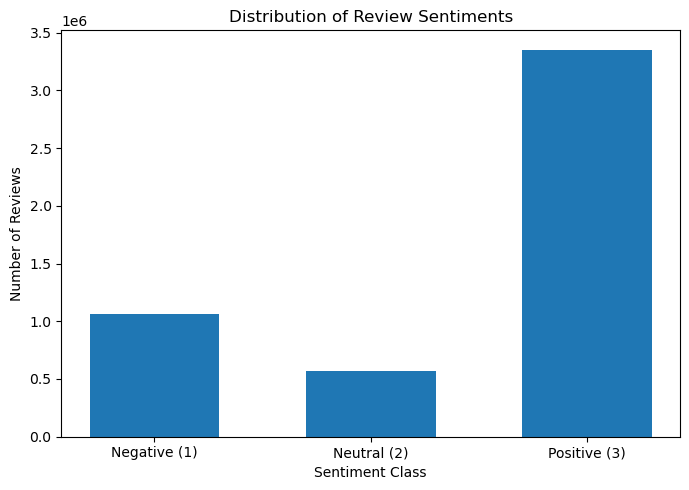

In [14]:
# Visualize the distribution of sentiments

# Define values and labels
counts = df['sentiment'].value_counts()
labels = ['Negative (1)', 'Neutral (2)', 'Positive (3)']
values = [counts.get(1), counts.get(2), counts.get(3)]

# Plot on figure
plt.figure(figsize=(7, 5))
bars = plt.bar(labels, values, width=0.6)

# Add graph info
plt.title('Distribution of Review Sentiments')
plt.xlabel('Sentiment Class')
plt.ylabel('Number of Reviews')

plt.tight_layout()
plt.show()


In [ ]:
# Per requirement, we need to use a balanced number of all sentiments
# Downsize the dataset to only include the same number of min class

# Verify original
print(f"Value counts before balancing: {df['sentiment'].value_counts()}")

# Get min value
min_size = df['sentiment'].value_counts().min()

# Ensures all classes in sentiment are set to min_size
df_final = (
    df.groupby('sentiment', group_keys=False)
    .apply(lambda x: x.sample(n=min_size, random_state=RAND_STATE))
)

# Ensures the data is shuffled.
df_final = df_final.sample(frac=1, random_state=RAND_STATE).reset_index(drop=True)

print(f"Value counts after balancing: {df_final['sentiment'].value_counts()}")

Value counts before balancing: sentiment
3    3351807
1    1059964
2     569206
Name: count, dtype: int64


/var/folders/bs/kf9zvh8n1ns0f5cdh1w0b_tr0000gn/T/ipykernel_64536/2612669399.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('sentiment', group_keys=False)


Value counts after balancing: sentiment
2    569206
3    569206
1    569206
Name: count, dtype: int64


In [19]:
# Final check of data structure
df_final.head(SANITY_SIZE)

,text,sentiment,text_len
0,I was glad that I was able to find a korean re...,2,289
1,Bloomsday is the quintessential Philly spot; F...,3,335
2,"What can I say.. It's Indian food, definitely...",2,176
3,The best!\n\nThe Bismarck is the best I have e...,3,265
4,Over all my experience would have been amazing...,2,1598
5,Best breakfast and brunch restaurant in Smyrna...,3,153
6,Really disappointing. Obviously I am in a mino...,1,477
7,"Even though I rarely go there, I've always lik...",2,479
8,This place is amazing! Ray and Madison made ou...,3,323
9,"Excellent! The food is delicious, portions lar...",3,773


In [20]:
# Save the final dataframe as a csv file for LSTM and DistilBERT models
df_final.to_csv('yelp_sentiments.csv', index=False, encoding='utf-8')